# Correction Workshop Rust for data science


## Polygon

Beforehand, I want to thanks `ohadravid`'s [work](https://ohadravid.github.io/posts/2023-03-rusty-python/) from which this exercice is from.

Let's now put in practice your skills in Python, Rust and PyO3. 

Go to `poly_match_rs` and activate your virtual environnement from the root of the project (at `rust_for_data_science/.`):
```bash
source .venv/bin/activate
```

**Don't forget to install the Python dependencies after activating your venv with `uv sync`**


## Context 

Imagine you have a list of polygons and a of list points, all in 2D. For business reasons, we want to “match” each point to a single polygon.

Our imaginary library is going to:

- Start with an initial list of points and polygons (all in 2D).
- For each point, find a much smaller subset of polygons that are closest to it, based on distance from the center.
- Out of those polygons, select the “best” one (we are going to use “smallest area” as “best”).

You will find in in the file `py_project/poly_match_v0.py` the baseline of our Python project that we want to optimize. The objective is now to speedup as much as possible by replacing some portions of code in Rust.


## Tests and measures

In order to check if the replaced code optimizes well, we will need a measurement tool. For that, there are two Python files already written that records the average time a version of the `poly_match` code takes.

- You will find `measure.py` that does the job only for one version :
```bash
python3 measure.py <module_name>
```

Where `<module_name>` refers to a version of the code and will be in the form `poly_match_v*` (omit `.py`)

- To compare every version of the code, run :
```bash
python3 measure_all.py
```

This will provide the average time execution of all and the speedup coefficient compared to the baseline which is `v0`.

Use `py-spy` ([GitHub](https://github.com/benfred/py-spy)) to analyse the time each function and subfunction takes. `py-spy` is a [sampling profiler](https://en.wikipedia.org/wiki/Profiling_(computer_programming)#Statistical_profilers) which can see into native frames.

It will allow us to generate [flamegraphs](https://www.brendangregg.com/FlameGraphs/cpuflamegraphs.html) in a `.svg` file that we will save in `rust_for_data_science/poly_match_rs/py_project/graphs/`. Run the command (at the current directory which is `poly_match/py_project`) :
```bash
sudo py-spy record -o graphs/profile.svg -- python measure.py poly_match_v0
```


#### Here is the FlameGraph for the file poly_match_v0


Run the command in your terminal (at the current directory which is `poly_match/py_project`), then, run the cell below; this will display the flamegraph `profile1` located in the `graph` folder.

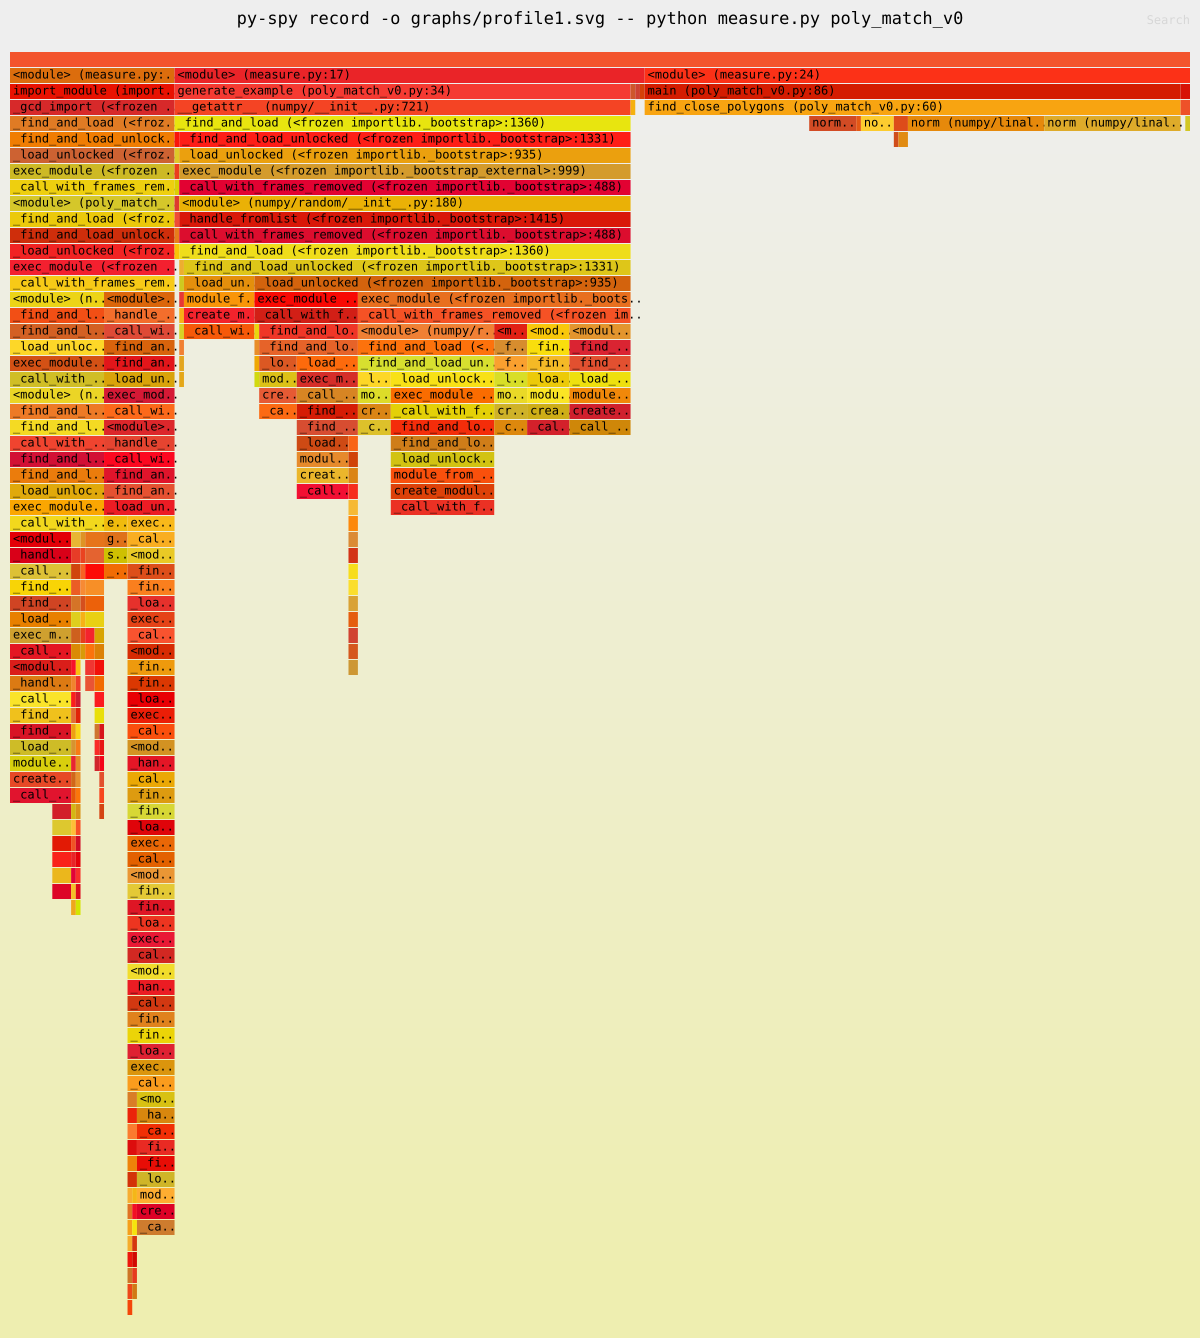

Measuring `poly_match_v0`
Took an avg of 134.77ms per iteration


In [37]:
from IPython.display import SVG, display
from pathlib import Path

p = Path("poly_match_rs/py_project/graphs/profile1.svg")  # adapte selon ton cwd

display(SVG(filename=str(p)))
!python3 poly_match_rs/py_project/measure.py poly_match_v0

## Exercice

At the end of each step/version of the code, we will generate a new flamegraph and analyse which portion of the code takes the longest to execute.

From a version to another, you can copy the previous code and overwrite your modification gradually.

### v0 - Baseline implementation in Python

The version 0 of the code is the naive implementation in Python. There is no Rust at all. The file `src/lib_v0.rs` matches `v0` but does nothing.

Let's take a look at the flamegraph using `py-spy` :
1. The vast majority of time is spent in the function `find_close_polygons`.
2. Most of that time is spend doing `norm`, which is a numpy function.

We are going to rewrite this function in Rust.


### v1 - Naive line-to-line translation of find_close_polygons

Go to `src/lib_v1.rs` and let's start coding. We want to translate the target function.

1. Rewrite `find_close_polygons` in Rust : copy the Python code of the function (in `poly_match_v0.py`) and translate line-to-line in Rust.
2. Add the function with `pyo3` to the module.
3. Take a look at `poly_match_v1.py` and check the differencies with the `v0`.
4. Compile the code using `maturin develop --release` for optimization. (**Run this command at the root of your Rust project `/poly_match_rs`**)
5. Run `measure.py` on both `v0` and `v1` and check average time execution.


<details>
    <summary><b>Need help?</b></summary>
         
> Translate `point` into an array using `as_array()`.

> As `center` is not defined in Rust (the class lives in Python), you must search for it directly in the object of type `Polygon`. 

> You can use `.getattr("center")?.extract::<PyReadonlyArray1\<f64>>()?.as_array()`

> `.norm()` must be applied to owned object. Use `.to_owned()` on `center`.

</details>
-

After translating the function into RUST and compiling the code, run the command 
```bash
sudo py-spy record -o graphs/profile2.svg -- python measure.py poly_match_v1
```
in the terminal, then run the cell below to visualize the flamegrap, looking at the profiler output, we can see a few interesting things

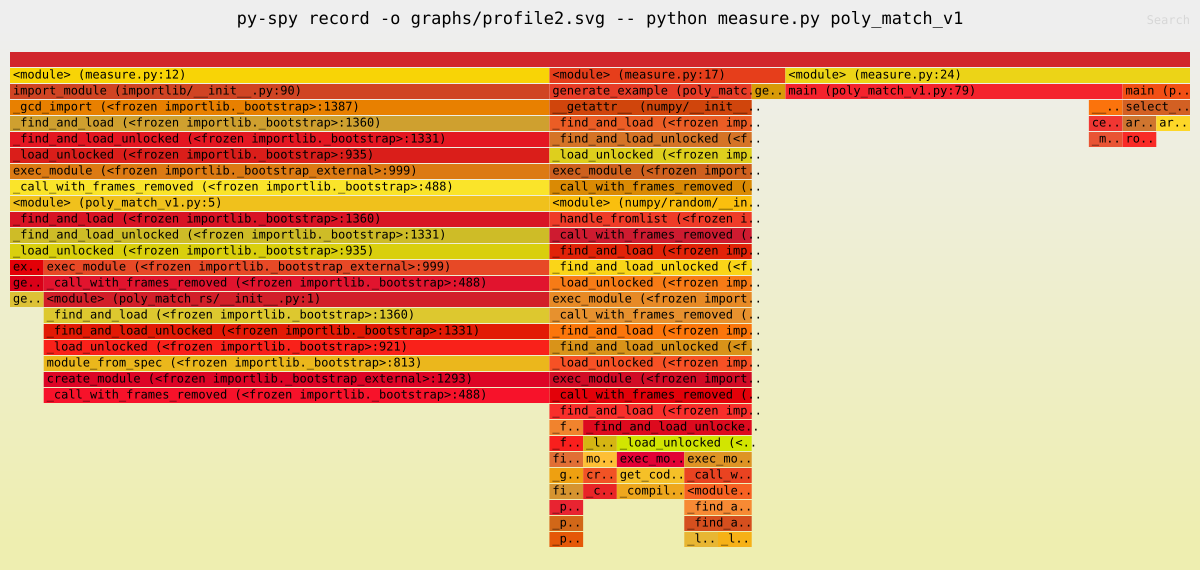

Measuring `poly_match_v1`
Took an avg of 18.08ms per iteration


In [38]:
p = Path("poly_match_rs/py_project/graphs/profile2.svg")  # adapte selon ton cwd

display(SVG(filename=str(p)))
!python3 poly_match_rs/py_project/measure.py poly_match_v1

1. The relative size of `find_close_polygons::...::trampoline` (the symbol Python directly calls) and `__pyfunction_find_close_polygons` (our actual implementation).
    - Hovering, they are 95% vs 88% of samples, so the overhead is pretty small.
2. The actual logic (`if (center - point).norm() < max_dist { ... }`) which is <span style="background-color: #2aa6cfff;">lib_v1.rs:22</span> (very small box on the right), is about 9% of the total runtime.
    - So x10 improvement should still be possible!
3. Most of the time is spent in <span style="background-color: #8cff5fff;">lib_v1.rs:16</span>, which is `poly.getattr(...).extract(...)` and if we zoom in we can see is really just `getattr` and getting the underlying array using `as_array`.

The conclusion here is that we need to focus on solving the 3rd point, and the way to do that is to rewrite `Polygon` in Rust.

### v2 - `Polygon` implementation in Rust (TODO)

Go to `src/lib_v2.rs` and translate the Python class `Polygon`to Rust.

We want to expose `poly.{x, y, center}` as properties and numpy Arrays.

1. Rewrite `Polygon` : we want to write a `struct Polygon` that contains `x`, `y` and `center`.
2. Add the class to the module. 
3. Write a constructor in the methods so that we can create new polygons.
4. Write the getters (if not already done).
5. Adapt `find_close_polygons` that now uses `Polygon` class in Rust.
3. Take a look at `poly_match_v2.py` and check the differencies with the `v1`.
6. Compile and measure time.


<details>
    <summary><b>Need help?</b></summary>
         
> ```rust
> #[new]
> fn new(x: PyReadonlyArray1<f64>, y: PyReadonlyArray1<f64>) -> Polygon { 
>         // TODO
>     }
> ```

> ```rust
> #[getter]
> fn x<'py>(&self, py: Python<'py>) -> PyResult<Bound<'py, PyArray1<f64>>> {
>     // TODO
> }
> ```

> `Ok(self.{field}.to_pyarray_bound(py))` to return a `Bound<'py, PyArray1<f64>>`.

> You can translate a `Vec` to an Array with `Array1::from_vec( // vec object )`

> To get the mean of an Array, use `.mean().unwrap()`.

> `.unwrap()` retrieves the value of `.mean()` if it exists. Otherwise, the value of `.mean()` is `None` and `.unwrap()` will panic and stop the program. We assume that the value of `x.mean()` is not empty for example.

> Instead of extracting from the Python class is not necessary anymore, we can just borrow the `center` field using `.borrow().center` then owning it with `.to_owned()`.

</details>
-

Let's check the profiler with `py-spy` : run the command 
```bash
sudo py-spy record -o graphs/profile3.svg -- python measure.py poly_match_v2
```
in the terminal, then run the cell below to visualize the flamegraph:

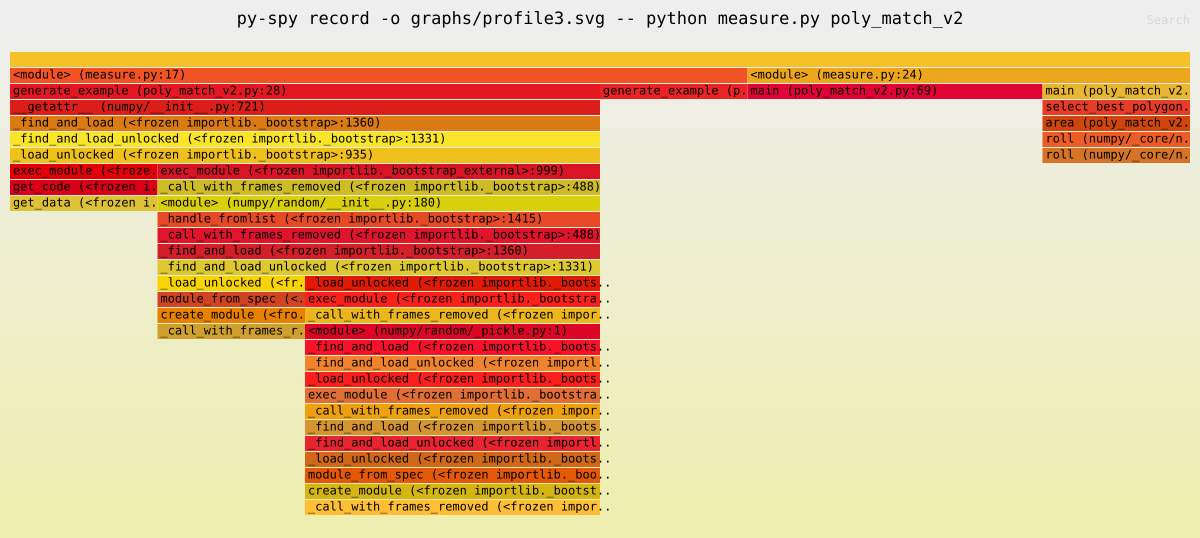

Measuring `poly_match_v2`
Took an avg of 4.70ms per iteration


In [39]:
p = Path("poly_match_rs/py_project/graphs/profile3.svg")  # adapte selon ton cwd

display(SVG(filename=str(p)))
!python3 poly_match_rs/py_project/measure.py poly_match_v2

1. We start to see `select_best_polygon`, which now calls some Rust code (when it gets the x & y vectors)
    - We could fix that, but that’s a very small potential improvement (maybe 10%)
2. We see we spend about 20% the time on `extract_argument` (under <span style="background-color: #ce68c9ff;">lib_v2.rs:48</span>), so we are still paying quite a lot on overhead!
    - But most of the time is in `PyIterator::next` and `PyTypeInfo::is_type_of`, which aren’t easy to fix.
3. We see a bunch of time spent allocating stuff!
    - <span style="background-color: #507df8ff;">lib_v2.rs:58</span> is our `if`, and we see `drop_in_place` and `to_owned`.
    - The actual line is about 35% of the overall time, which is a lot more than we expect: this should be the “fast bit” with all the data in place.


Let’s tackle the last point.

This our problematic code :
```rust
let center = poly.borrow(py).center
    .to_owned();

if (center - point).norm() < max_dist { ... } 
```

### v3 - Optimized allocations (TODO)



Go to `src/lib_v3.rs` (`poly_match_v2` and `poly_match_v3` should be the same as we only want to modify the inner of a Rust function that preserves the same behavior).

What we want is to avoid that `to_owned`. But we need an owned object for `norm`, so we’ll have to implement that manually.

**Note** : The reason we can improve on ndarray here is that we know that our array is actually just 2 `f32s`.

1. Import `ndarray_linalg::Scalar` at the top of the file.
2. Adapt the code to avoid using `to_owned`, ie. try not to use the function `.norm()`.
4. Compile and measure time.

<details>
    <summary><b>Need help?</b></summary>
         
> Define an object called `norm` of type float in which is defined `center` and the mathematical expression of the norm between `center` and `point` 

> To catch the `center` of each `poly`, you pass by the reference by doing `&poly.borrow().center`.

</details>
-

We now expect to see our 100x speedup of the initial code `poly_match_v0`.


Let's check the profiler with `py-spy` : run the command 
```bash
sudo py-spy record -o graphs/profile4.svg -- python measure.py poly_match_v3
```
in the terminal, then run the cell below to visualize the flamegraph:


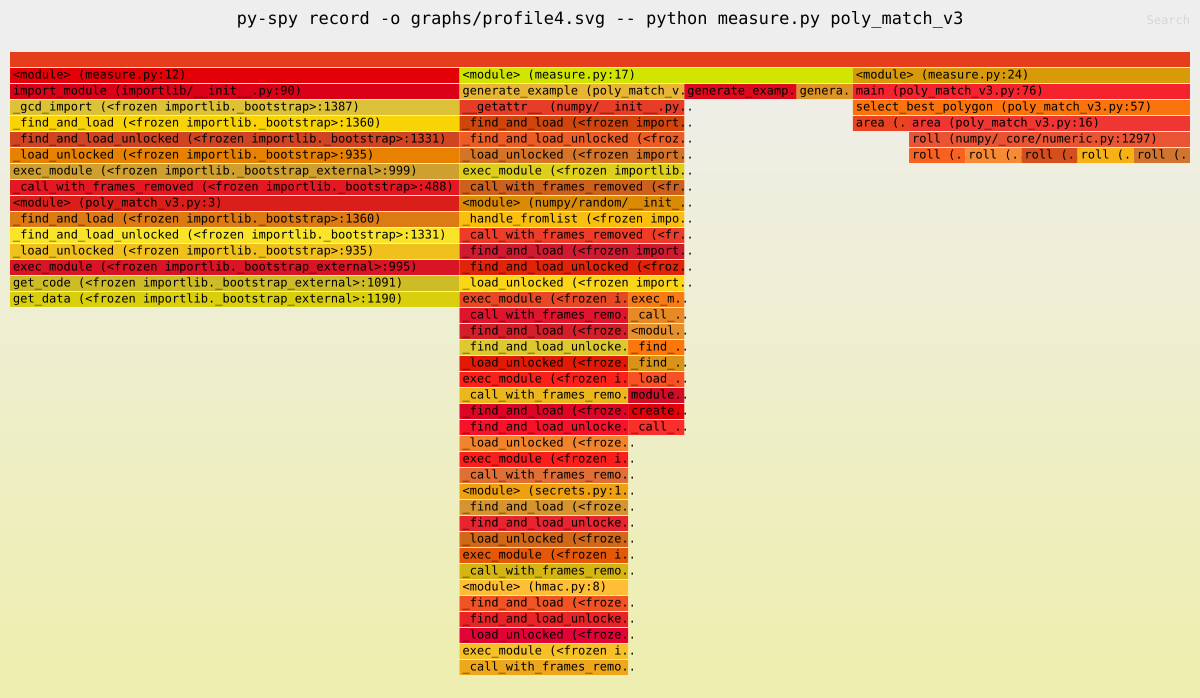

Measuring `poly_match_v3`
Took an avg of 2.09ms per iteration


In [40]:
p = Path("poly_match_rs/py_project/graphs/profile4.svg")  # adapte selon ton cwd

display(SVG(filename=str(p)))
!python3 poly_match_rs/py_project/measure.py poly_match_v3

### v4 - Move outer loop to Rust (Optional)

Check `src/lib_v4.rs` and `poly_match_v4.rs`.

This version of the code is a more recent update from `ohadravid` that should speedup even more, up to 360 times faster compared to the initial time execution.

You can check and analyse the code and identify the changes that is efficient for a max optimization.

Let's check the profiler with `py-spy` : run the command 
```bash
sudo py-spy record -o graphs/profile5.svg -- python measure.py poly_match_v4
```
in the terminal, then run the cell below to visualize the flamegraph:

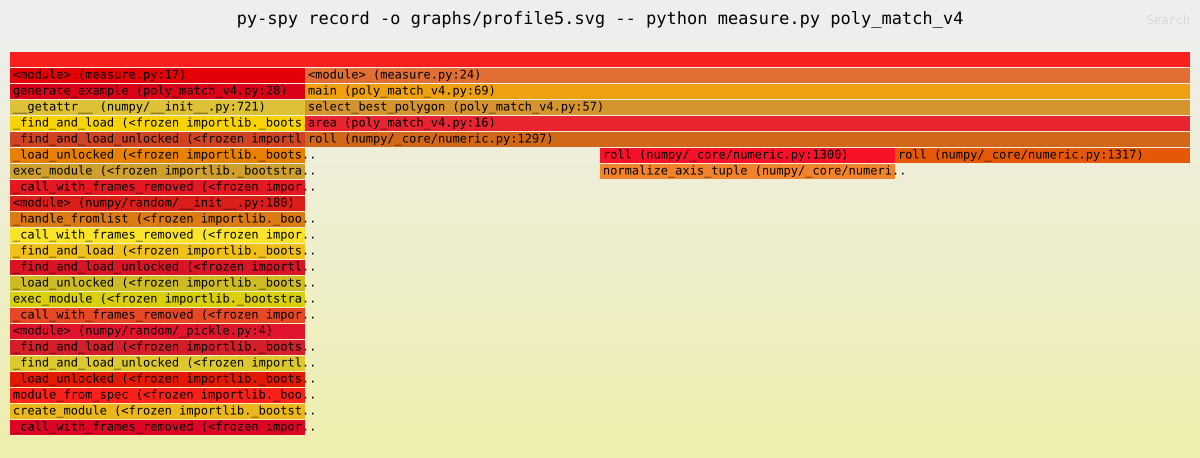

Measuring `poly_match_v4`
Took an avg of 1.27ms per iteration


In [41]:
p = Path("poly_match_rs/py_project/graphs/profile5.svg")  # adapte selon ton cwd

display(SVG(filename=str(p)))
!python3 poly_match_rs/py_project/measure.py poly_match_v4